##Taller 02 Poda Alfa-Beta / Grupo 04


In [10]:
import random
import matplotlib.pyplot as plt
import networkx as nx
from math import inf

###Configuración manual del árbol

In [11]:
# Árbol de prueba. Se puede modificar directamente desde esta celda.
arbol = [
    [5, 4, 3],
    [2, 1, 0],
    [9, 8, 7]
]

###Generación aleatoria de árbol

In [12]:
def generar_arbol_aleatorio(niveles, hojas, minimo=-10, maximo=10):
    """
    Genera un árbol con una cantidad determinada de niveles y hojas.
    Los niveles incluyen la raíz.
    """

    if niveles < 2 or niveles > 5:
        raise ValueError("Los niveles deben estar entre 2 y 5.")

    if hojas < 1 or hojas > 50:
        raise ValueError("Las hojas deben estar entre 1 y 50.")

    # Cuando llegamos al último nivel, generamos los valores de las hojas.
    if niveles == 2:
        return [
            random.randint(minimo, maximo)
            for _ in range(hojas)
        ]

    # Cada hijo necesita como mínimo 2 hojas para conservar la profundidad.
    minimo_por_hijo = 2 ** (niveles - 2)

    if hojas < minimo_por_hijo * 2:
        raise ValueError(
            f"No hay suficientes hojas para construir {niveles} niveles."
        )

    max_hijos = min(4, hojas // minimo_por_hijo)
    cantidad_hijos = random.randint(2, max_hijos)

    # Repartimos las hojas entre los hijos del nodo actual.
    distribucion = [minimo_por_hijo] * cantidad_hijos
    restantes = hojas - sum(distribucion)

    while restantes > 0:
        i = random.randint(0, cantidad_hijos - 1)
        distribucion[i] += 1
        restantes -= 1

    return [
        generar_arbol_aleatorio(
            niveles - 1,
            cantidad,
            minimo,
            maximo
        )
        for cantidad in distribucion
    ]

###Validación de restricciones

In [13]:
def validar_arbol(arbol, max_niveles=5, max_hojas=50):
    if not isinstance(arbol, list) or not arbol:
        raise ValueError("El árbol debe ser una lista no vacía.")

    hojas = 0
    profundidad_maxima = 0

    def recorrer(nodo, profundidad):
        nonlocal hojas, profundidad_maxima

        profundidad_maxima = max(
            profundidad_maxima,
            profundidad
        )

        if isinstance(nodo, list):
            if not nodo:
                raise ValueError("No se permiten listas vacías.")

            for hijo in nodo:
                recorrer(hijo, profundidad + 1)

        elif isinstance(nodo, (int, float)):
            hojas += 1

        else:
            raise TypeError(
                "Los nodos internos deben ser listas y las hojas números."
            )

    recorrer(arbol, 1)

    if profundidad_maxima > max_niveles:
        raise ValueError(
            f"El árbol supera el máximo de {max_niveles} niveles."
        )

    if hojas > max_hojas:
        raise ValueError(
            f"El árbol supera el máximo de {max_hojas} hojas."
        )

    return hojas, profundidad_maxima

###Algoritmo Alfa-Beta

In [14]:
def poda_alfa_beta(arbol):
    hojas, niveles = validar_arbol(arbol)

    nodos = {}
    aristas = []
    contador = 0

    # Primero registramos todo el árbol para poder visualizarlo después.
    def registrar_nodos(nodo, ruta=(), profundidad=0):
        nonlocal contador

        contador += 1

        if isinstance(nodo, list):
            tipo = "MAX" if profundidad % 2 == 0 else "MIN"
            valor = None
        else:
            tipo = "HOJA"
            valor = nodo

        nodos[ruta] = {
            "id": contador,
            "profundidad": profundidad,
            "tipo": tipo,
            "valor": valor,
            "visitado": False,
            "podado": False
        }

        if isinstance(nodo, list):
            for i, hijo in enumerate(nodo):
                nueva_ruta = ruta + (i,)

                aristas.append(
                    (ruta, nueva_ruta)
                )

                registrar_nodos(
                    hijo,
                    nueva_ruta,
                    profundidad + 1
                )

    registrar_nodos(arbol)

    # Marca un subárbol como podado sin evaluarlo.
    def marcar_podado(ruta):
        nodos[ruta]["podado"] = True

        for otra_ruta in nodos:
            if (
                len(otra_ruta) > len(ruta)
                and otra_ruta[:len(ruta)] == ruta
            ):
                nodos[otra_ruta]["podado"] = True

    def minimax(nodo, ruta, profundidad, alfa, beta, es_max):
        nodos[ruta]["visitado"] = True

        # Las hojas simplemente devuelven su valor.
        if not isinstance(nodo, list):
            return nodo

        if es_max:
            mejor_valor = -inf

            for i, hijo in enumerate(nodo):
                nueva_ruta = ruta + (i,)

                valor = minimax(
                    hijo,
                    nueva_ruta,
                    profundidad + 1,
                    alfa,
                    beta,
                    False
                )

                mejor_valor = max(mejor_valor, valor)
                alfa = max(alfa, mejor_valor)

                # Si Alfa supera a Beta, el resto de esta rama se poda.
                if alfa >= beta:
                    for j in range(i + 1, len(nodo)):
                        marcar_podado(ruta + (j,))
                    break

        else:
            mejor_valor = inf

            for i, hijo in enumerate(nodo):
                nueva_ruta = ruta + (i,)

                valor = minimax(
                    hijo,
                    nueva_ruta,
                    profundidad + 1,
                    alfa,
                    beta,
                    True
                )

                mejor_valor = min(mejor_valor, valor)
                beta = min(beta, mejor_valor)

                # Si Beta queda por debajo de Alfa, ya no necesitamos continuar.
                if alfa >= beta:
                    for j in range(i + 1, len(nodo)):
                        marcar_podado(ruta + (j,))
                    break

        nodos[ruta]["valor"] = mejor_valor

        return mejor_valor

    valor_optimo = minimax(
        arbol,
        (),
        0,
        -inf,
        inf,
        True
    )

    return {
        "raiz": (),
        "valor_optimo": valor_optimo,
        "nodos": nodos,
        "aristas": aristas,
        "cantidad_hojas": hojas,
        "niveles": niveles
    }

###Encontrar la ruta óptima

In [15]:
def obtener_ruta_optima(resultado):
    nodos = resultado["nodos"]

    ruta = [()]
    actual = ()

    while nodos[actual]["tipo"] != "HOJA":

        hijos = [
            ruta_hijo
            for ruta_hijo in nodos
            if (
                len(ruta_hijo) == len(actual) + 1
                and ruta_hijo[:len(actual)] == actual
                and nodos[ruta_hijo]["visitado"]
            )
        ]

        if not hijos:
            break

        if nodos[actual]["tipo"] == "MAX":
            actual = max(
                hijos,
                key=lambda x: nodos[x]["valor"]
            )
        else:
            actual = min(
                hijos,
                key=lambda x: nodos[x]["valor"]
            )

        ruta.append(actual)

    return ruta

###Visualización

In [16]:
def dibujar_arbol(resultado):
    nodos = resultado["nodos"]
    aristas = resultado["aristas"]
    ruta = obtener_ruta_optima(resultado)

    G = nx.DiGraph()

    for ruta_nodo in nodos:
        G.add_node(ruta_nodo)

    G.add_edges_from(aristas)

    posiciones = {}
    hojas = [
        ruta_nodo
        for ruta_nodo, datos in nodos.items()
        if datos["tipo"] == "HOJA"
    ]

    posiciones_hojas = {
        ruta_nodo: i
        for i, ruta_nodo in enumerate(hojas)
    }

    def calcular_x(ruta_nodo):
        if ruta_nodo in posiciones_hojas:
            return posiciones_hojas[ruta_nodo]

        hijos = [
            hijo
            for hijo in nodos
            if (
                len(hijo) == len(ruta_nodo) + 1
                and hijo[:len(ruta_nodo)] == ruta_nodo
            )
        ]

        return sum(
            calcular_x(hijo)
            for hijo in hijos
        ) / len(hijos)

    for ruta_nodo, datos in nodos.items():
        posiciones[ruta_nodo] = (
            calcular_x(ruta_nodo),
            -datos["profundidad"]
        )

    aristas_ruta = [
        (ruta[i], ruta[i + 1])
        for i in range(len(ruta) - 1)
    ]

    aristas_podadas = [
        arista
        for arista in aristas
        if nodos[arista[1]]["podado"]
    ]

    aristas_normales = [
        arista
        for arista in aristas
        if (
            arista not in aristas_ruta
            and arista not in aristas_podadas
        )
    ]

    nodos_normales = [
        ruta_nodo
        for ruta_nodo, datos in nodos.items()
        if not datos["podado"]
    ]

    nodos_podados = [
        ruta_nodo
        for ruta_nodo, datos in nodos.items()
        if datos["podado"]
    ]

    plt.figure(
        figsize=(
            max(14, len(hojas) * 0.7),
            max(8, resultado["niveles"] * 2)
        )
    )

    # Ramas evaluadas que no forman parte de la jugada óptima.
    nx.draw_networkx_edges(
        G,
        posiciones,
        edgelist=aristas_normales,
        edge_color="gray",
        arrows=False
    )

    # Ramas descartadas mediante Alfa-Beta.
    nx.draw_networkx_edges(
        G,
        posiciones,
        edgelist=aristas_podadas,
        edge_color="red",
        style="dashed",
        width=2,
        arrows=False
    )

    # Ramas que forman la secuencia óptima.
    nx.draw_networkx_edges(
        G,
        posiciones,
        edgelist=aristas_ruta,
        edge_color="green",
        width=3,
        arrows=False
    )

    nx.draw_networkx_nodes(
        G,
        posiciones,
        nodelist=nodos_normales,
        node_size=1400,
        node_color="white",
        edgecolors="black"
    )

    nx.draw_networkx_nodes(
        G,
        posiciones,
        nodelist=nodos_podados,
        node_size=1200,
        node_color="white",
        edgecolors="red",
        node_shape="X"
    )

    etiquetas = {}

    for ruta_nodo, datos in nodos.items():

        if datos["podado"]:
            etiquetas[ruta_nodo] = "PODA"

        elif datos["tipo"] == "HOJA":
            etiquetas[ruta_nodo] = str(datos["valor"])

        else:
            etiquetas[ruta_nodo] = (
                f"{datos['tipo']}\n{datos['valor']}"
            )

    nx.draw_networkx_labels(
        G,
        posiciones,
        labels=etiquetas,
        font_size=9
    )

    plt.title(
        f"Poda Alfa-Beta | Valor óptimo = "
        f"{resultado['valor_optimo']}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

###Ejecución - Generación de árbol manual

RESULTADO DE PODA ALFA-BETA
-----------------------------------
Valor óptimo: 7
Niveles: 3
Hojas: 9
Nodos evaluados: 11
Nodos podados: 2

Ruta óptima:
MAX → 7
MIN → 7
HOJA → 7


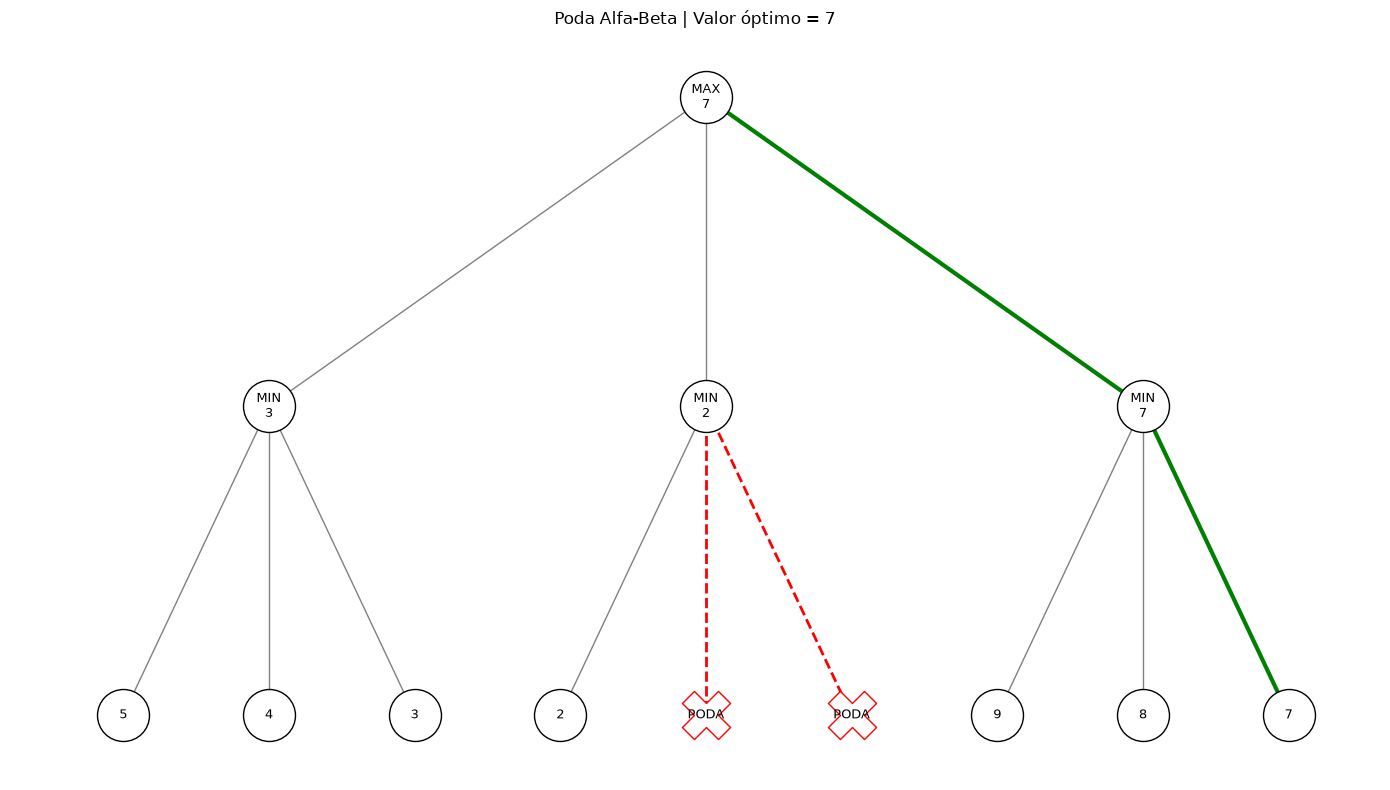

In [17]:
resultado = poda_alfa_beta(arbol)
ruta = obtener_ruta_optima(resultado)

nodos = resultado["nodos"]

nodos_evaluados = sum(
    1
    for datos in nodos.values()
    if datos["visitado"]
)

nodos_podados = sum(
    1
    for datos in nodos.values()
    if datos["podado"]
)

print("RESULTADO DE PODA ALFA-BETA")
print("-" * 35)
print(f"Valor óptimo: {resultado['valor_optimo']}")
print(f"Niveles: {resultado['niveles']}")
print(f"Hojas: {resultado['cantidad_hojas']}")
print(f"Nodos evaluados: {nodos_evaluados}")
print(f"Nodos podados: {nodos_podados}")

print("\nRuta óptima:")

for ruta_nodo in ruta:
    datos = nodos[ruta_nodo]

    if datos["tipo"] == "HOJA":
        print(f"HOJA → {datos['valor']}")
    else:
        print(f"{datos['tipo']} → {datos['valor']}")

dibujar_arbol(resultado)

###Ejecución - Generación de árbol aleatoria

[[-9, 9, -2, -4, 9], [-1, 2, 10, -8], [9, 9, 7]]
Valor óptimo: 7


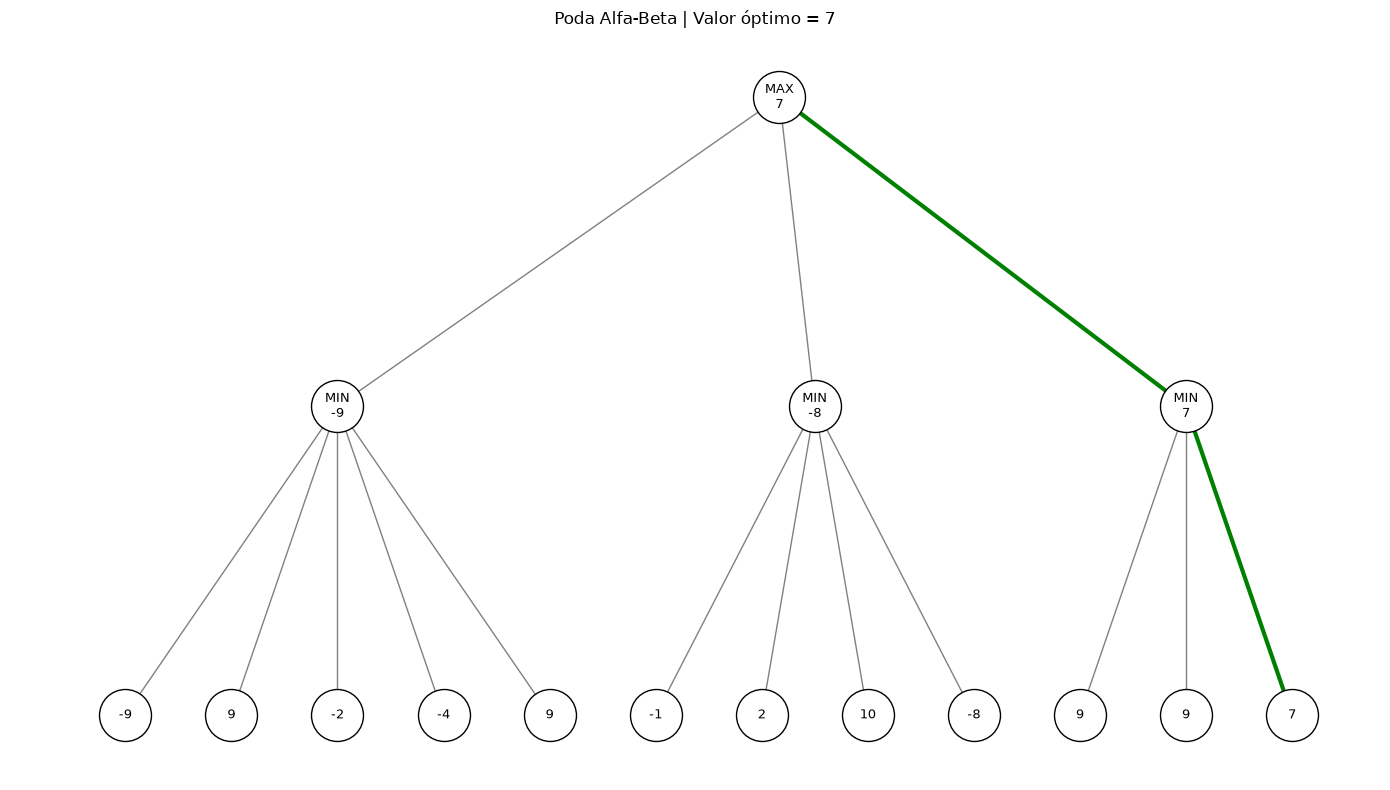

In [18]:
arbol = generar_arbol_aleatorio(3, 12)
resultado = poda_alfa_beta(arbol)

print(arbol)
print("Valor óptimo:", resultado["valor_optimo"])

dibujar_arbol(resultado)